In [72]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [73]:
#Read in file
df = pd.read_csv(
    "https://raw.githubusercontent.com/GloBIAS-BioimageAnalysts/Survey_2024/main/data/survey2024_headersandcommascleaned_recleaned.csv"
)

In [74]:
#Clean data
df.columns = df.columns.str.strip().str.replace('\n', ' ', regex=True)

In [75]:
column_list = df.columns.tolist()
print(column_list)


['Timestamp', 'What is your gender', 'What is your age group', 'Which of these describe your position Choose all options that apply', 'Are you currently in a permanent position', 'In which of these sectors do you work', 'What is your location', 'Q1 How would you describe your work  Choose all options that apply', 'Q2 Which of the following do you work in Choose all options that apply', 'Q3 Where do bioimage analysts sit in your institution Choose all options that apply', 'Q4 If you work in a facility what are the operatingorbusiness models of your facility Choose all options that apply Please do not answer if you do not work in a facility', 'Q5 If you work in a facility how much of your budget comes from each of these Please do not answer if you do not work in a facility (grants you apply for)', 'Q5 If you work in a facility how much of your budget comes from each of these Please do not answer if you do not work in a facility (grants someone else applies for)', 'Q5 If you work in a fac

In [76]:
duties_col = 'Q6 How many of the following do you do as part of your typical job Choose all options that apply'
career_col = 'Which of these describe your position Choose all options that apply'

In [77]:
df_multi = df.copy()

df_multi[duties_col] = df_multi[duties_col].astype(str).str.split(',')
df_multi[career_col] = df_multi[career_col].astype(str).str.split(',')

In [78]:
df_exploded = (
    df_multi
    .explode(duties_col)
    .explode(career_col)
)

In [79]:
df_exploded[duties_col] = df_exploded[duties_col].str.strip()
df_exploded[career_col] = df_exploded[career_col].str.strip()

df_exploded = df_exploded[
    (df_exploded[duties_col] != '') &
    (df_exploded[career_col] != '')
]

In [80]:
duties_vs_career = (
    df_exploded
    .groupby([career_col, duties_col])
    .size()
    .unstack(fill_value=0)
)

duties_vs_career

Q6 How many of the following do you do as part of your typical job Choose all options that apply,bioimage analysis infrastructure development and maintenance,bioimage analysis instruction,bioimage analysis services,bioimage analysis tool development (not bound to a single service project),management / administration,nan,own bioimage analysis project
Which of these describe your position Choose all options that apply,,,,,,,
AI and Analysis,1,1,1,1,1,0,1
Assistant Professor,1,0,1,0,1,0,0
Associate Pofessor,0,1,0,0,1,0,1
Associate Professor,0,1,0,0,0,0,1
Clinical data scientist,0,0,0,0,0,1,0
Director of Data,1,1,1,1,1,0,1
IT Staff,1,1,0,1,1,0,0
Industrial Materials Scientist,0,0,0,0,0,1,0
Industry researcher,1,1,1,1,1,0,1


In [81]:
duties_vs_career_pct = (
    duties_vs_career
    .div(duties_vs_career.sum(axis=1), axis=0) * 100
)

duties_vs_career_pct.round(1)

Q6 How many of the following do you do as part of your typical job Choose all options that apply,bioimage analysis infrastructure development and maintenance,bioimage analysis instruction,bioimage analysis services,bioimage analysis tool development (not bound to a single service project),management / administration,nan,own bioimage analysis project
Which of these describe your position Choose all options that apply,,,,,,,
AI and Analysis,16.7,16.7,16.7,16.7,16.7,0.0,16.7
Assistant Professor,33.3,0.0,33.3,0.0,33.3,0.0,0.0
Associate Pofessor,0.0,33.3,0.0,0.0,33.3,0.0,33.3
Associate Professor,0.0,50.0,0.0,0.0,0.0,0.0,50.0
Clinical data scientist,0.0,0.0,0.0,0.0,0.0,100.0,0.0
Director of Data,16.7,16.7,16.7,16.7,16.7,0.0,16.7
IT Staff,25.0,25.0,0.0,25.0,25.0,0.0,0.0
Industrial Materials Scientist,0.0,0.0,0.0,0.0,0.0,100.0,0.0
Industry researcher,16.7,16.7,16.7,16.7,16.7,0.0,16.7


In [87]:
role_map = {
    'PhD student': 'Student',
    'MSc student': 'Student',
    'postdoctoral researcher': 'Academic research',
    'professor': 'Academic leadership',
    'Assistant Professor': 'Academic leadership',
    'Associate Professor': 'Academic leadership',
    'junior group leader': 'Academic leadership',
    'core facility head': 'Core facility',
    'staff scientist in a core facility': 'Core facility',
    'staff scientist researcher': 'Core facility',
    'research engineer': 'Technical staff',
    'Research Engineer': 'Technical staff',
    'Software Application Specialist': 'Technical staff',
    'IT Staff': 'Technical staff',
    'Industry scientist': 'Industry',
    'Industry researcher': 'Industry',
    'Research Director': 'Leadership',
    'Director of Data, AI and Analysis': 'Leadership'
}

df_exploded['RoleGroup'] = df_exploded[career_col].map(role_map)

In [88]:
df_exploded = df_exploded[
    df_exploded['RoleGroup'].notna() &
    df_exploded[duties_col].notna() &
    (df_exploded['RoleGroup'].str.lower() != 'nan') &
    (df_exploded[duties_col].str.lower() != 'nan') &
    (df_exploded['RoleGroup'] != '') &
    (df_exploded[duties_col] != '')
]

In [89]:
table = (
    df_exploded
    .dropna(subset=['RoleGroup'])
    .groupby(['RoleGroup', duties_col])
    .size()
    .unstack(fill_value=0)
)

table_pct = table.div(table.sum(axis=1), axis=0) * 100

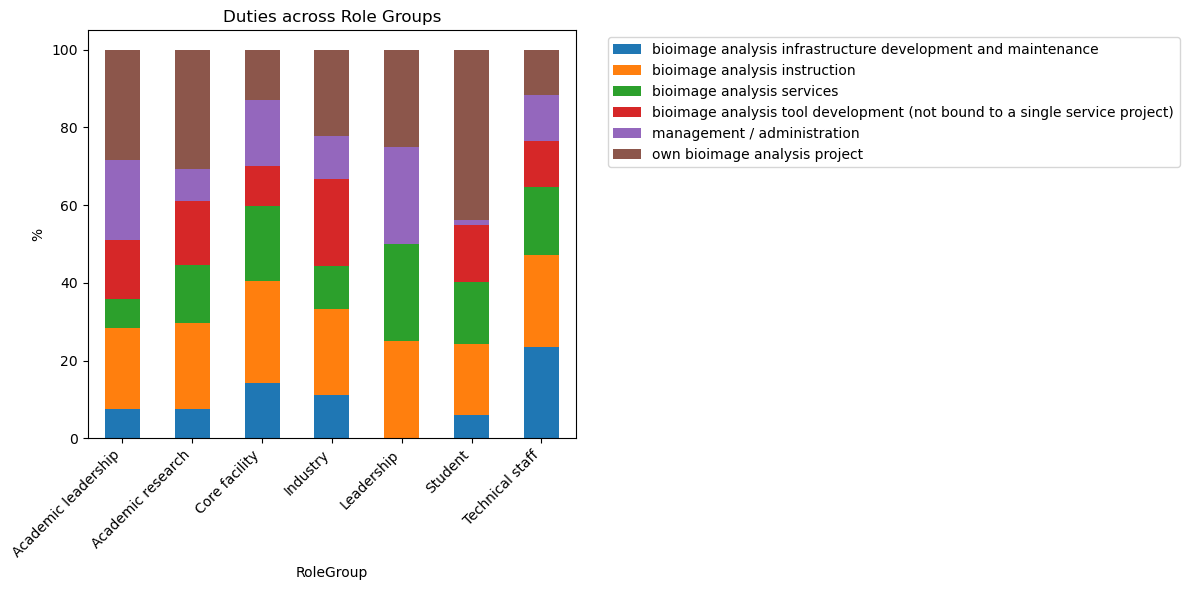

In [90]:
table_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.ylabel('%')
plt.title('Duties across Role Groups')
plt.legend(bbox_to_anchor=(1.05,1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

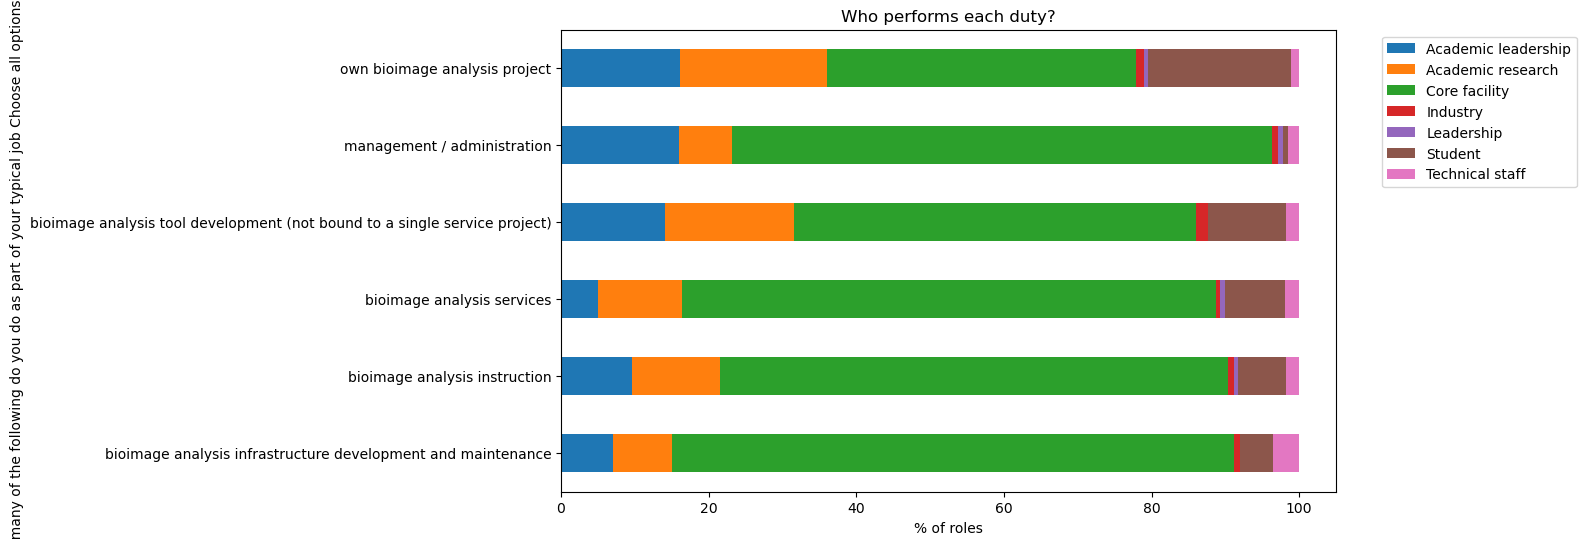

In [91]:
duties_focus = (
    df_exploded
    .groupby([duties_col, 'RoleGroup'])
    .size()
    .unstack(fill_value=0)
)

duties_focus_pct = duties_focus.div(duties_focus.sum(axis=1), axis=0) * 100

duties_focus_pct.plot(kind='barh', stacked=True, figsize=(10,6))
plt.legend(bbox_to_anchor=(1.05,1))

plt.xlabel('% of roles')
plt.title('Who performs each duty?')
plt.show()

In [92]:
table = (
    df_exploded
    .groupby(['RoleGroup', duties_col])
    .size()
    .unstack(fill_value=0)
)

table_pct = table.div(table.sum(axis=1), axis=0) * 100

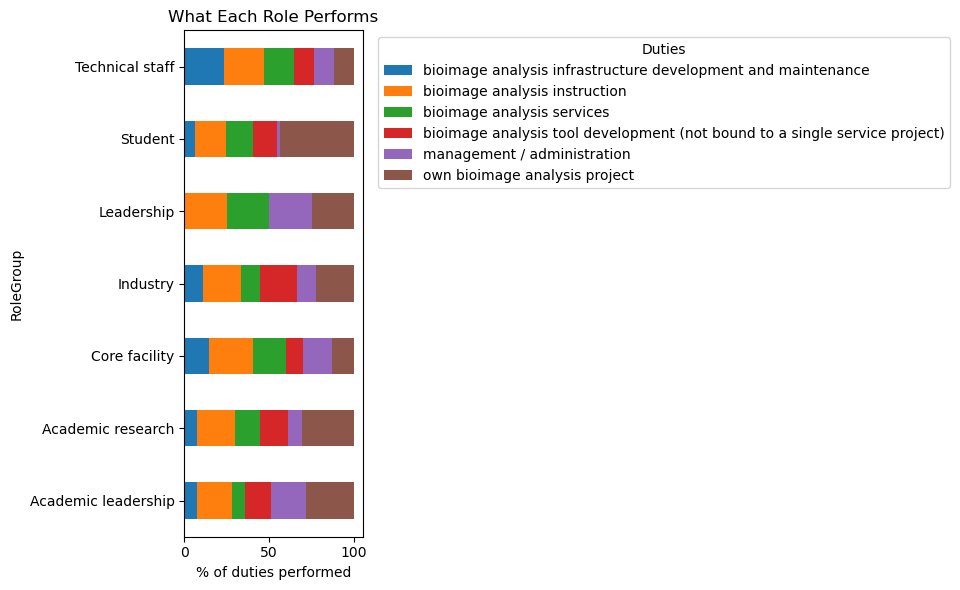

In [93]:
table_pct.plot(
    kind='barh',
    stacked=True,
    figsize=(10,6)
)

plt.xlabel('% of duties performed')
plt.title('What Each Role Performs')
plt.legend(title='Duties', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [94]:
duties_by_role = (
    df_exploded
    .groupby([duties_col, 'RoleGroup'])
    .size()
    .unstack(fill_value=0)
)

In [95]:
duties_by_role_pct = (
    duties_by_role
    .div(duties_by_role.sum(axis=1), axis=0) * 100
)

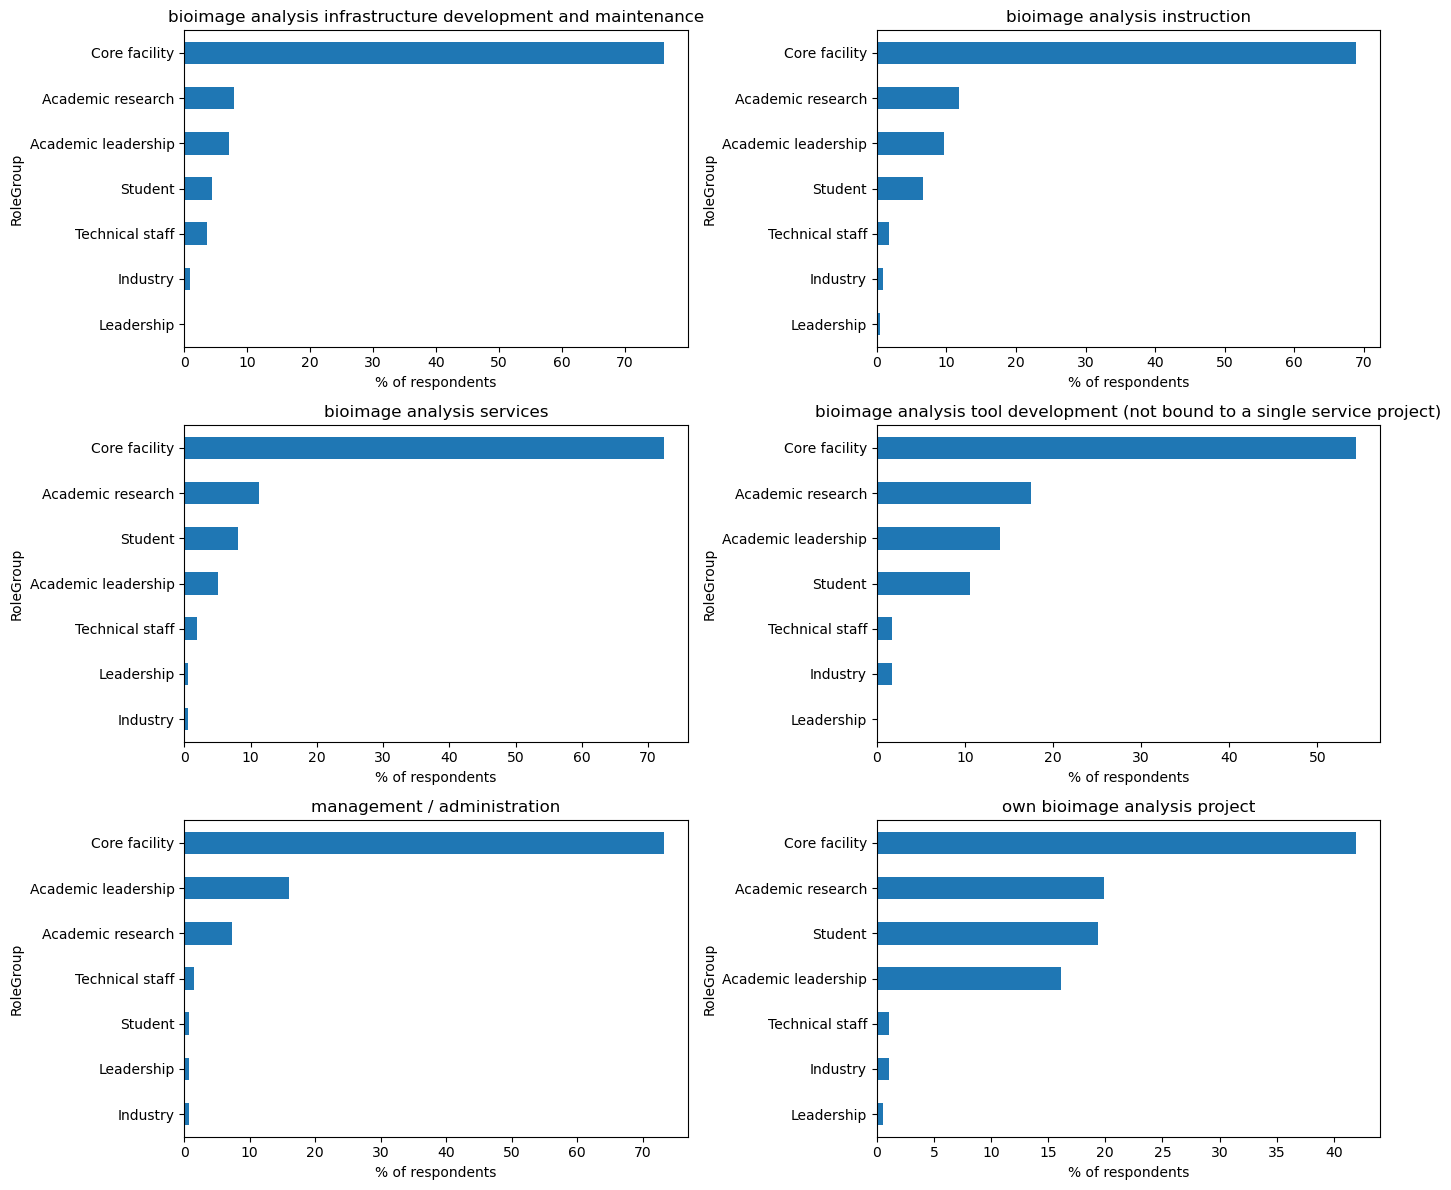

In [96]:
duties = duties_by_role_pct.index

n = len(duties)
cols = 2
rows = (n + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 4))
axes = axes.flatten()

for i, duty in enumerate(duties):
    duties_by_role_pct.loc[duty].sort_values().plot(
        kind='barh',
        ax=axes[i]
    )
    axes[i].set_title(duty)
    axes[i].set_xlabel('% of respondents')

# remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

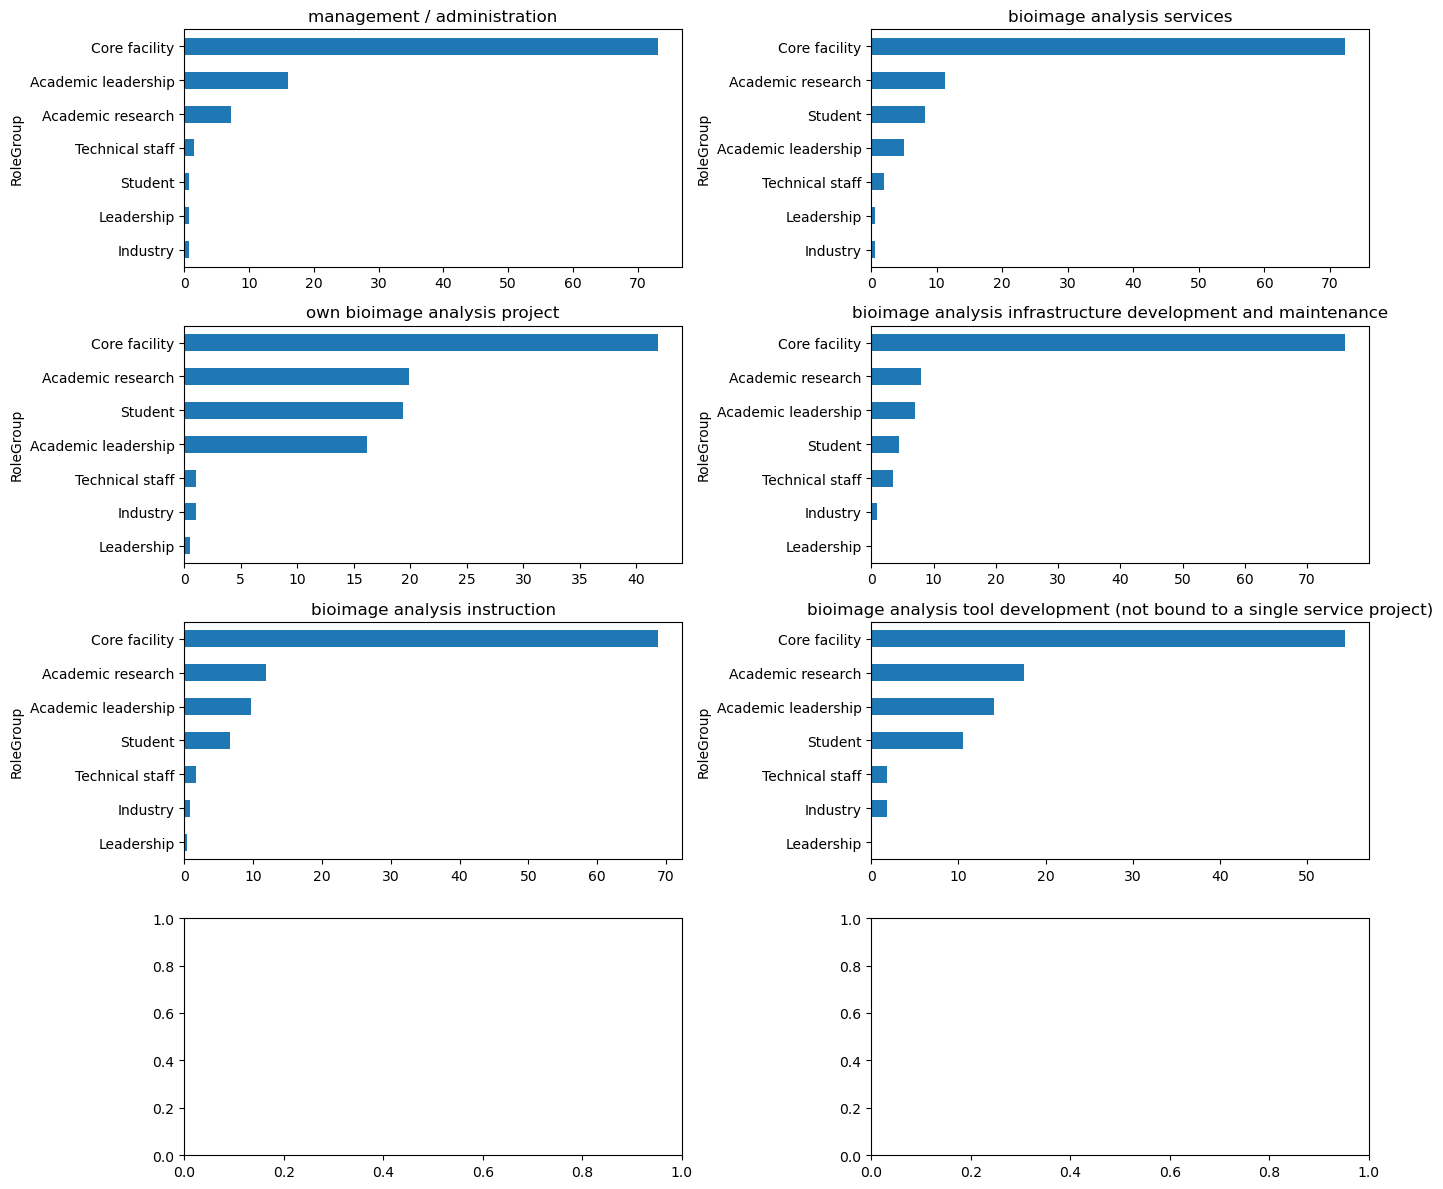

In [98]:
top_duties = duties_by_role_pct.sum(axis=1).sort_values(ascending=False).head(8).index
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, duty in enumerate(top_duties):
    duties_by_role_pct.loc[duty].sort_values().plot(
        kind='barh',
        ax=axes[i]
    )
    axes[i].set_title(duty)

plt.tight_layout()
plt.show()

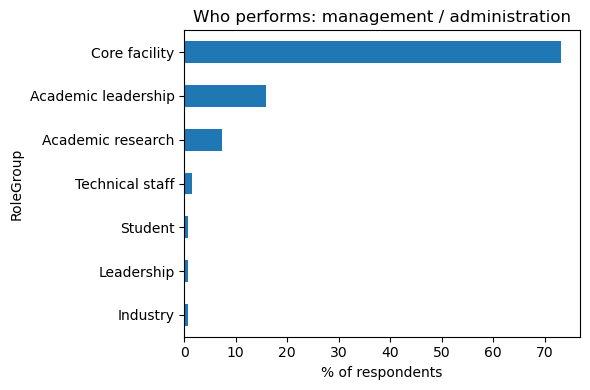

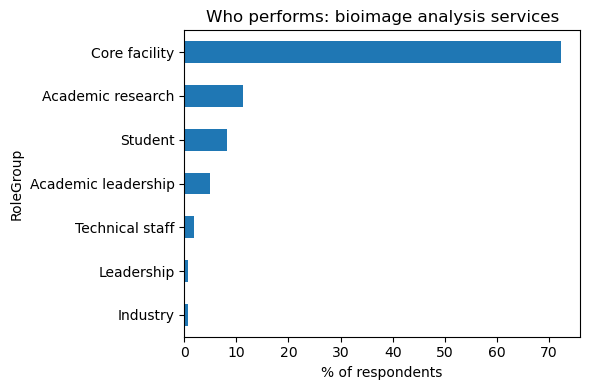

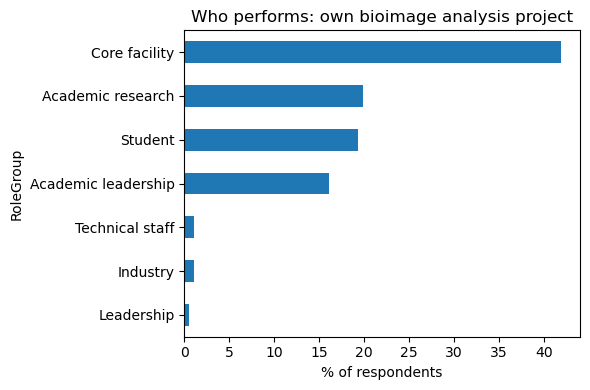

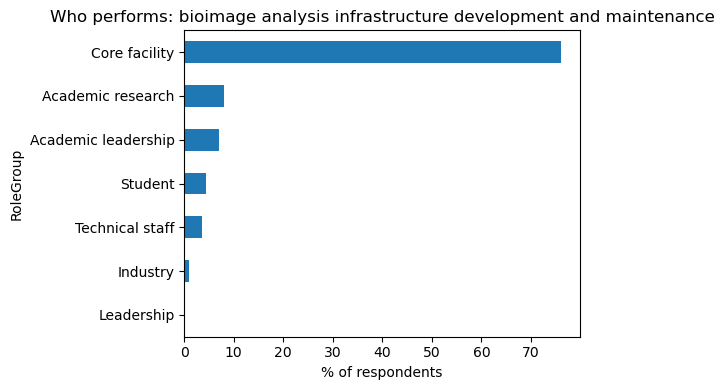

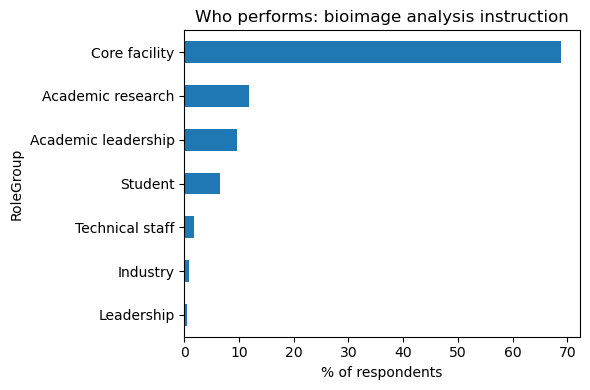

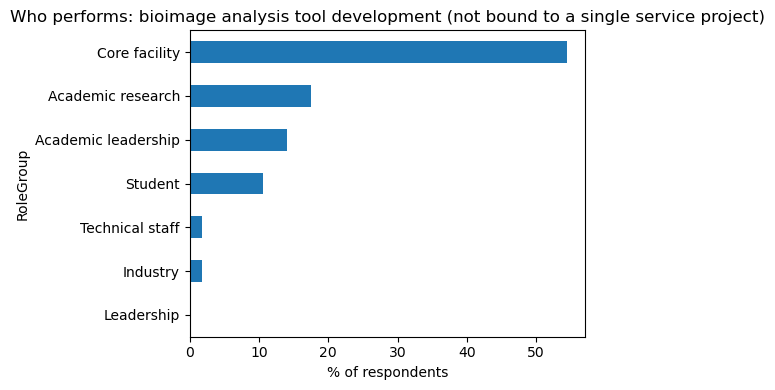

In [99]:
for duty in top_duties:
    plt.figure(figsize=(6,4))
    duties_by_role_pct.loc[duty].sort_values().plot(kind='barh')

    plt.title(f'Who performs: {duty}')
    plt.xlabel('% of respondents')
    plt.tight_layout()
    plt.show()